# Insurance Data Profile — freMTPL2

French Motor Third-Party Liability dataset. 678K policies, ~5% claim rate.  
Key targets: **claim frequency**, **severity**, **pure premium** (= freq × sev).  
Pricing goal: estimate expected pure premium per unit exposure accurately enough to outbid competitors on good risks without adverse selection.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

freq = pd.read_parquet('../data/insurance/fremtpl2_freq_raw.parquet')
sev  = pd.read_parquet('../data/insurance/fremtpl2_sev_raw.parquet')
proc = pd.read_parquet('../data/insurance/processed.parquet')

print(f'Freq:      {freq.shape}   | Sev: {sev.shape}')
print(f'Processed: {proc.shape}')
print(f'Claim rate: {proc.claim_flag.mean():.2%} | Policies with claims: {proc.claim_flag.sum():,}')

Freq:      (678013, 12)   | Sev: (26639, 2)
Processed: (678013, 17)
Claim rate: 5.02% | Policies with claims: 34,060


## 1. Raw Data Structure

In [2]:
print('=== Frequency table (one row per policy) ===')
display(freq.describe(include='all').T)
print('\n=== Severity table (one row per claim payment) ===')
display(sev.describe().T)
print(f'\nNote: {len(sev):,} claim records for {proc.claim_flag.sum():,} policies with ClaimNb>0')
print(f'Multiple claims per policy possible — sev is aggregated to policy level in processed.')

=== Frequency table (one row per policy) ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
IDpol,678013.0,NaN,NaN,NaN,2621856.921071,1641782.752655,1.0,1157951.0,2272152.0,4046274.0,6114330.0
ClaimNb,678013.0,NaN,NaN,NaN,0.053247,0.240117,0.0,0.0,0.0,0.0,16.0
Exposure,678013.0,NaN,NaN,NaN,0.52875,0.364442,0.002732,0.18,0.49,0.99,2.01
Area,678013,6,C,191880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VehPower,678013.0,NaN,NaN,NaN,6.454631,2.050906,4.0,5.0,6.0,7.0,15.0
VehAge,678013.0,NaN,NaN,NaN,7.044265,5.666232,0.0,2.0,6.0,11.0,100.0
DrivAge,678013.0,NaN,NaN,NaN,45.499122,14.137444,18.0,34.0,44.0,55.0,100.0
BonusMalus,678013.0,NaN,NaN,NaN,59.761502,15.636658,50.0,50.0,50.0,64.0,230.0
VehBrand,678013,11,B12,166024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VehGas,678013,2,'Regular',345877,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== Severity table (one row per claim payment) ===


,count,mean,std,min,25%,50%,75%,max
IDpol,26639.0,2.279864e+06,1.577202e+06,139.0,1087642.50,2137413.0,3180162.00,6113971.00
ClaimAmount,26639.0,2.278536e+03,2.929748e+04,1.0,686.81,1172.0,1228.08,4075400.56



Note: 26,639 claim records for 34,060 policies with ClaimNb>0
Multiple claims per policy possible — sev is aggregated to policy level in processed.


## 2. Target Variables

Three modelling targets:
- **`claim_freq`** — claim count (Poisson / NB model)
- **`severity`** — avg cost per claim given claim>0 (Gamma model)
- **`pure_premium`** — total cost / exposure (Tweedie / hurdle model)

Heavy right tails + zero-inflation are the core statistical challenge.

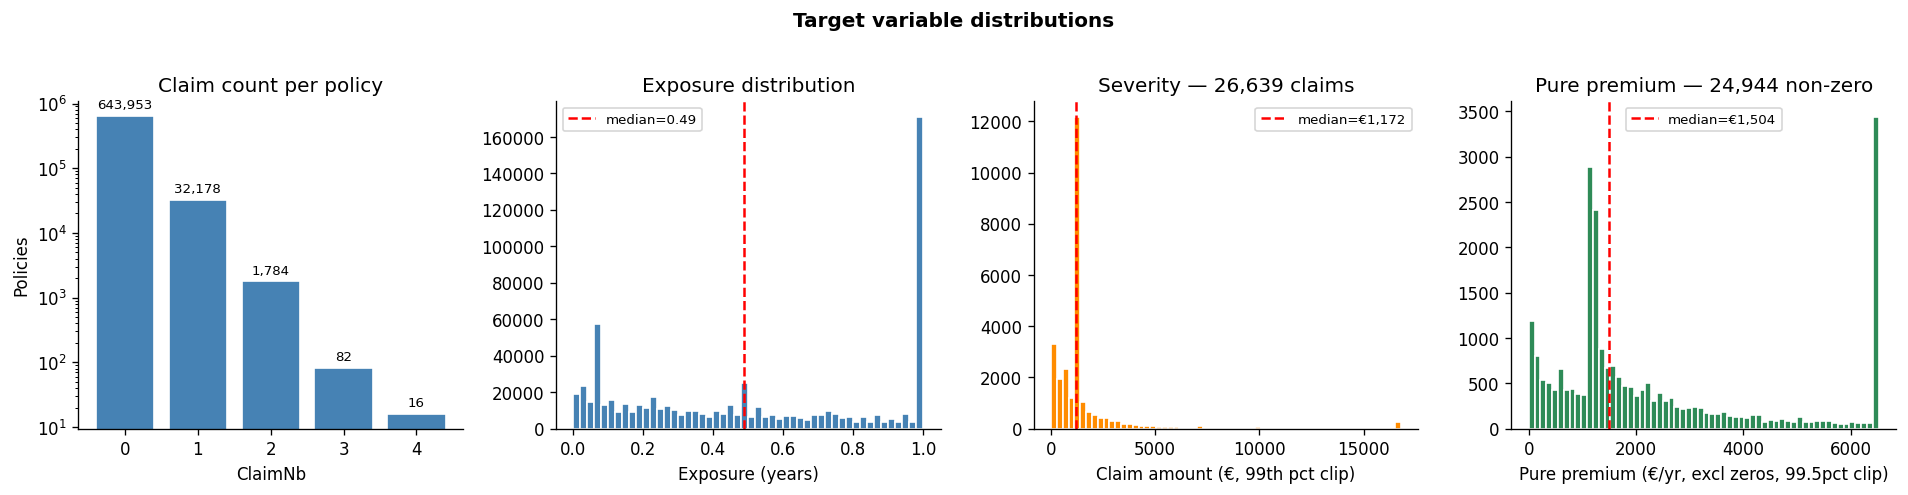

=== Target summary ===
Claim rate (% policies):          5.02%
Mean ClaimNb per policy:           0.0532
Mean severity (claimants only):    €2,222
Median severity:                   €1,172
Severity 95th pct:                 €4,659
Severity max:                      €4,075,401
Mean pure premium (all policies):  €383


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Claim count distribution
ax = axes[0]
claim_counts = proc['ClaimNb'].value_counts().sort_index()
ax.bar(claim_counts.index, claim_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('ClaimNb')
ax.set_ylabel('Policies')
ax.set_title('Claim count per policy')
ax.set_yscale('log')
for i, (k, v) in enumerate(claim_counts.items()):
    ax.text(k, v * 1.3, f'{v:,}', ha='center', fontsize=8)

# Exposure distribution
ax = axes[1]
ax.hist(proc['Exposure'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Exposure (years)')
ax.set_title('Exposure distribution')
ax.axvline(proc['Exposure'].median(), color='red', linestyle='--', label=f'median={proc["Exposure"].median():.2f}')
ax.legend(fontsize=8)

# Severity (claims only)
ax = axes[2]
sev_vals = sev['ClaimAmount'].clip(upper=sev['ClaimAmount'].quantile(0.99))
ax.hist(sev_vals, bins=60, color='darkorange', edgecolor='white')
ax.set_xlabel('Claim amount (€, 99th pct clip)')
ax.set_title(f'Severity — {len(sev):,} claims')
ax.axvline(sev['ClaimAmount'].median(), color='red', linestyle='--', label=f'median=€{sev["ClaimAmount"].median():,.0f}')
ax.legend(fontsize=8)

# Pure premium (non-zero policies)
ax = axes[3]
pp = proc.loc[proc['pure_premium'] > 0, 'pure_premium'].clip(upper=proc['pure_premium'].quantile(0.995))
ax.hist(pp, bins=60, color='seagreen', edgecolor='white')
ax.set_xlabel('Pure premium (€/yr, excl zeros, 99.5pct clip)')
ax.set_title(f'Pure premium — {len(pp):,} non-zero')
ax.axvline(pp.median(), color='red', linestyle='--', label=f'median=€{pp.median():,.0f}')
ax.legend(fontsize=8)

plt.suptitle('Target variable distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== Target summary ===')
print(f"Claim rate (% policies):          {proc['claim_flag'].mean():.2%}")
print(f"Mean ClaimNb per policy:           {proc['ClaimNb'].mean():.4f}")
print(f"Mean severity (claimants only):    €{proc['severity'].dropna().mean():,.0f}")
print(f"Median severity:                   €{proc['severity'].dropna().median():,.0f}")
print(f"Severity 95th pct:                 €{proc['severity'].dropna().quantile(0.95):,.0f}")
print(f"Severity max:                      €{proc['severity'].dropna().max():,.0f}")
print(f"Mean pure premium (all policies):  €{proc['pure_premium'].mean():,.0f}")

## 3. Feature Distributions

**BonusMalus** is the most predictive single feature — it encodes the insurer's own rolling risk signal.  
50 = clean driver, >100 = malus, max 230.

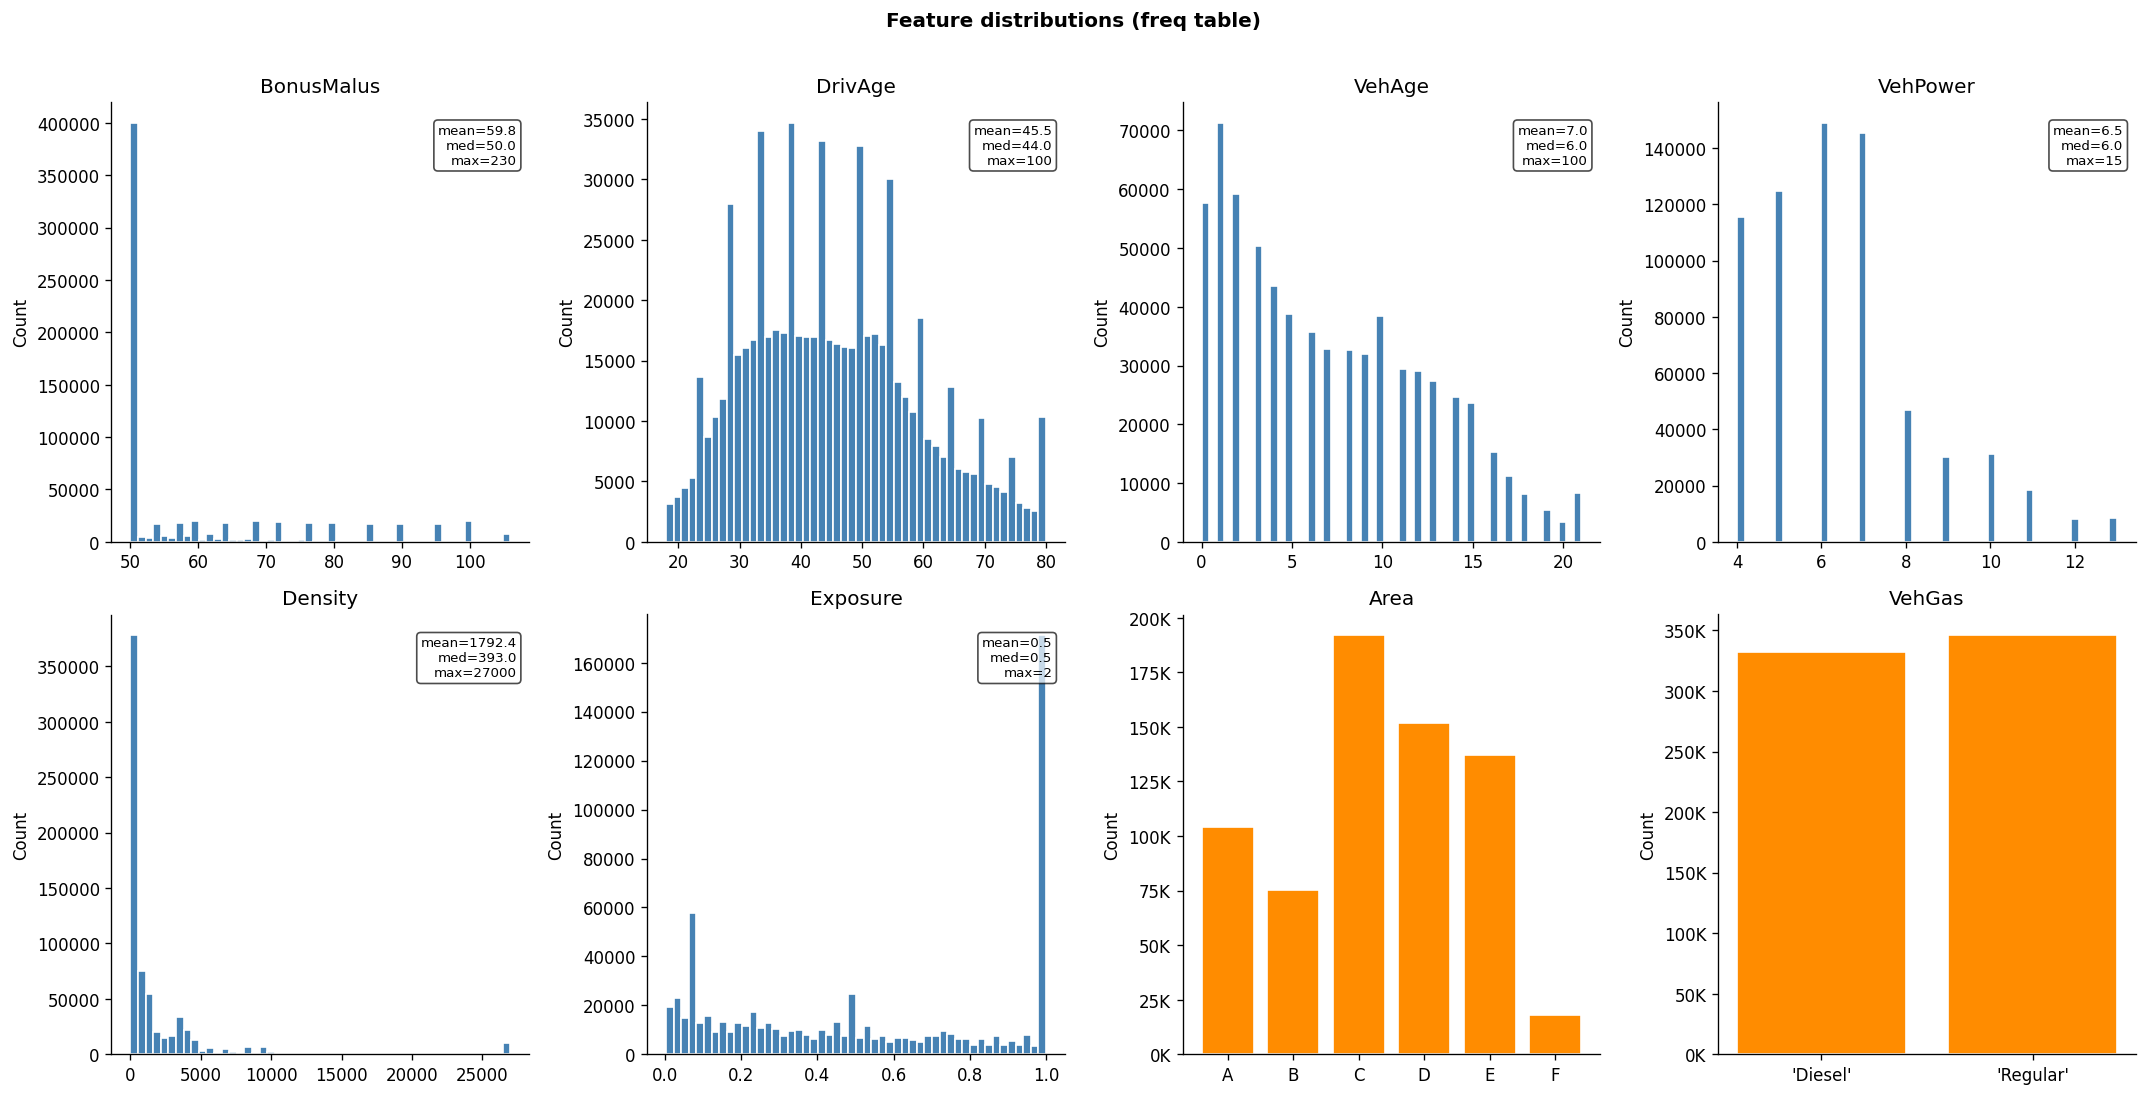

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

numeric_feats = ['BonusMalus', 'DrivAge', 'VehAge', 'VehPower', 'Density', 'Exposure']
cat_feats = ['Area', 'VehGas']

for i, col in enumerate(numeric_feats):
    ax = axes[i]
    data = freq[col]
    ax.hist(data.clip(upper=data.quantile(0.99)), bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.text(0.97, 0.95, f'mean={data.mean():.1f}\nmed={data.median():.1f}\nmax={data.max():.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

for i, col in enumerate(cat_feats):
    ax = axes[len(numeric_feats) + i]
    vc = freq[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='darkorange', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('Feature distributions (freq table)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

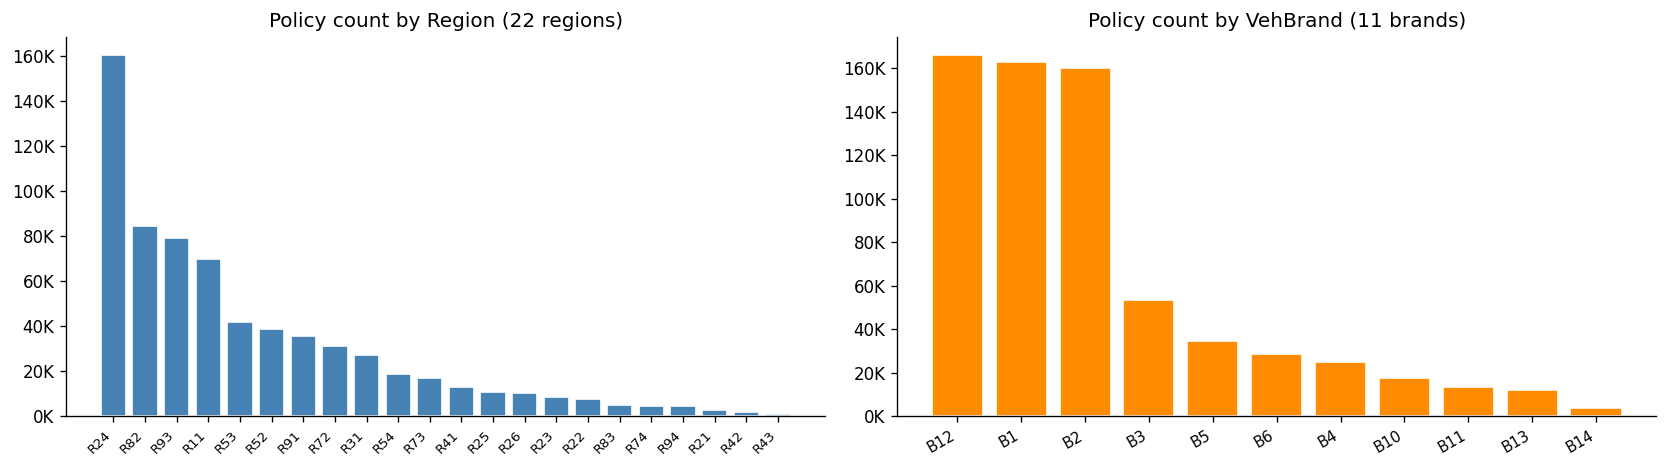

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Region policy count
ax = axes[0]
region_counts = freq['Region'].value_counts()
ax.bar(range(len(region_counts)), region_counts.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(region_counts)))
ax.set_xticklabels(region_counts.index.astype(str), rotation=45, ha='right', fontsize=8)
ax.set_title(f'Policy count by Region ({freq["Region"].nunique()} regions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# VehBrand
ax = axes[1]
brand_counts = freq['VehBrand'].value_counts()
ax.bar(range(len(brand_counts)), brand_counts.values, color='darkorange', edgecolor='white')
ax.set_xticks(range(len(brand_counts)))
ax.set_xticklabels(brand_counts.index.astype(str), rotation=30, ha='right', fontsize=9)
ax.set_title(f'Policy count by VehBrand ({freq["VehBrand"].nunique()} brands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

## 4. Claim Frequency by Feature

Empirical claim rates — what a GLM or GBM needs to learn. Monotone or non-linear?  
Note: raw rates ignore exposure weighting, so interpret carefully for partial-year policies.

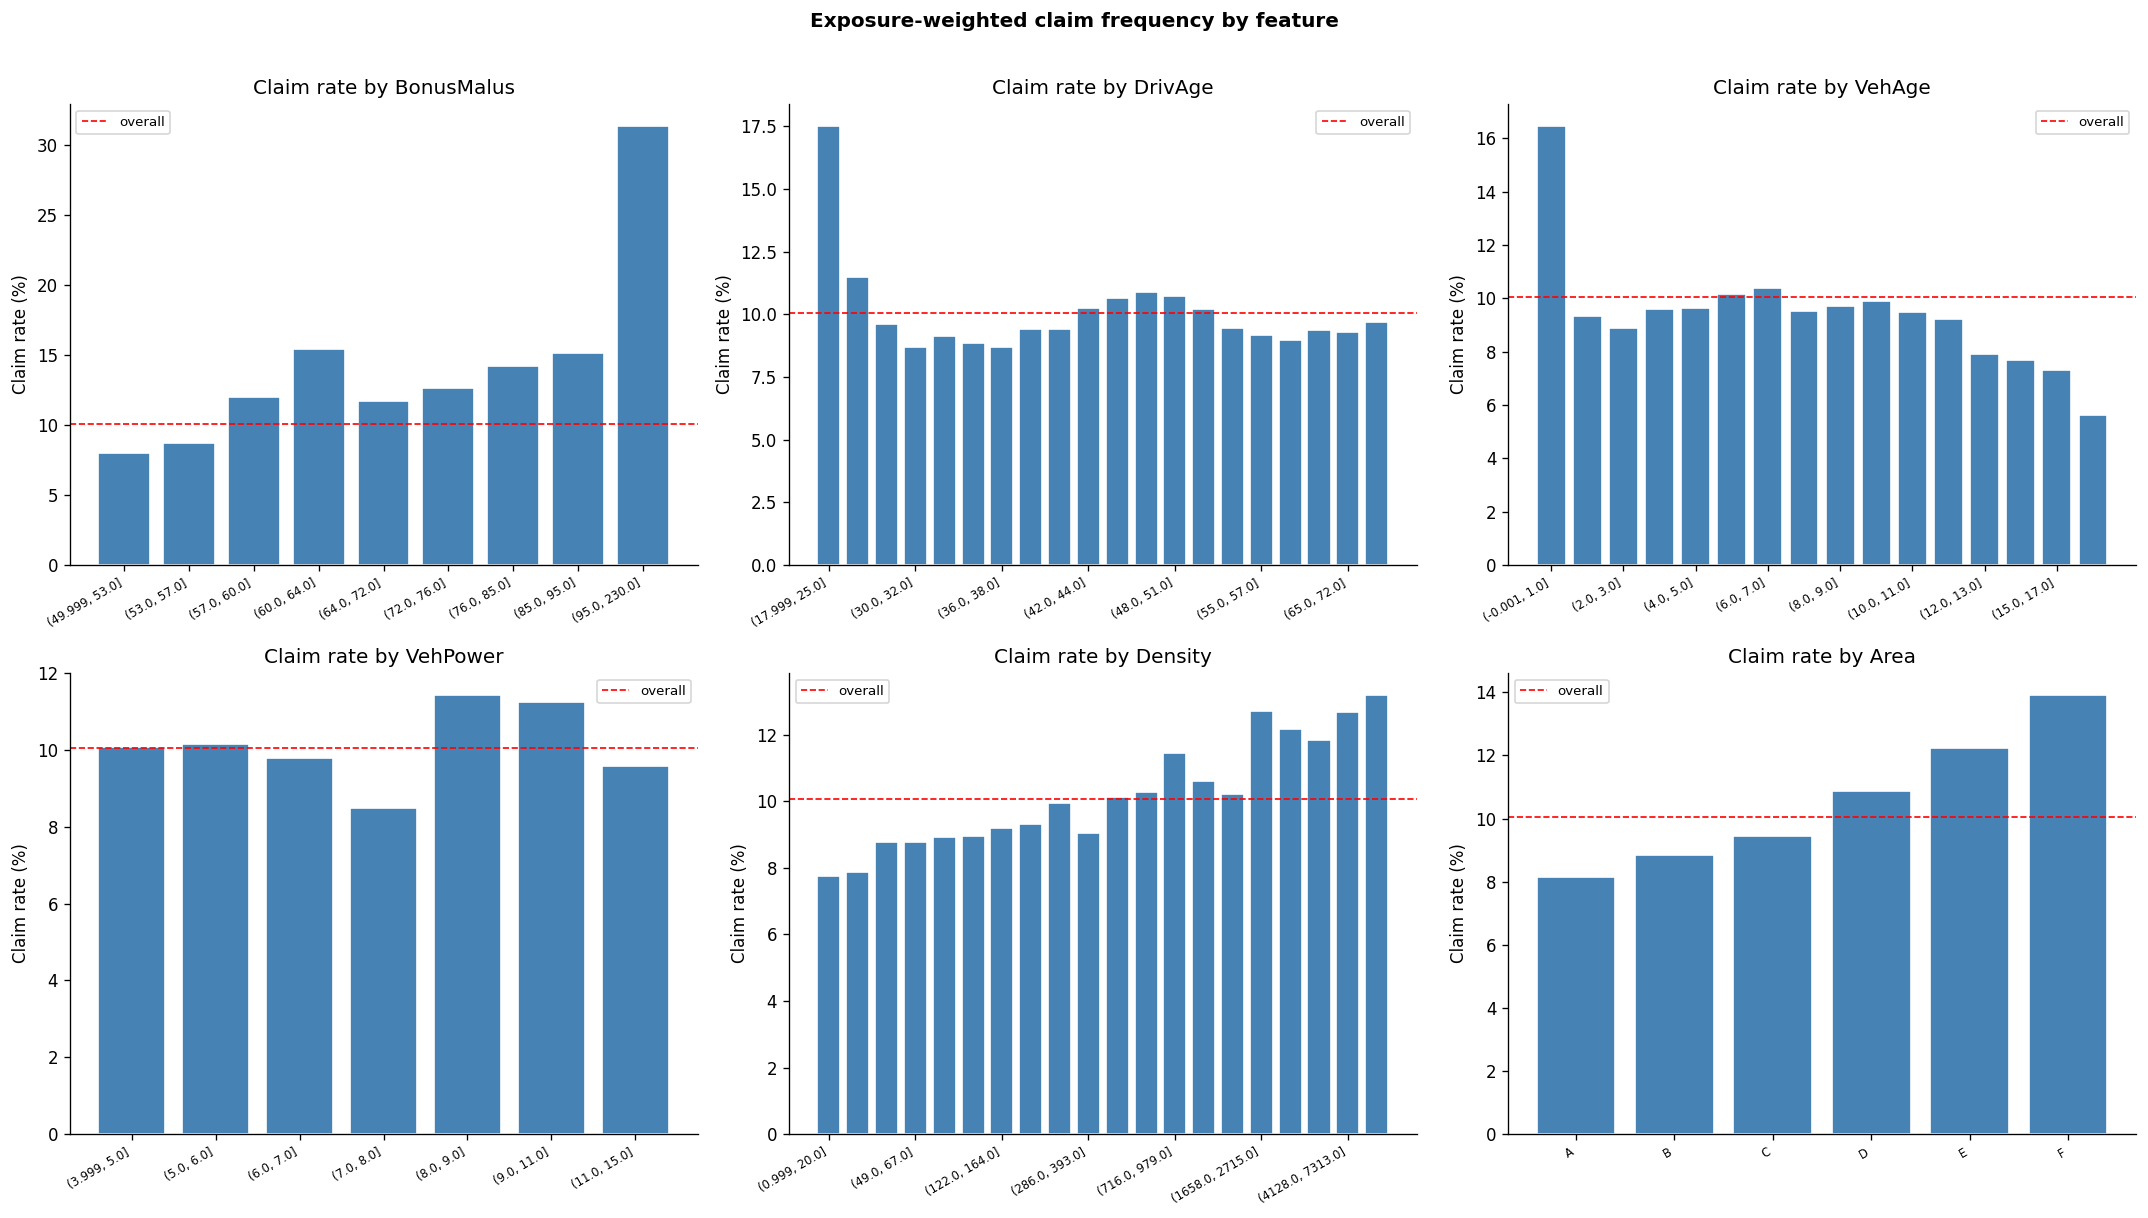

Overall claim frequency (annualised): 0.1006 claims/year (10.06%)


In [6]:
def exposure_weighted_claim_rate(df, col, n_bins=20, quantile_bins=True):
    """Exposure-weighted claim rate: total_claims / total_exposure per bin."""
    d = df[[col, 'ClaimNb', 'Exposure']].copy()
    if quantile_bins and d[col].dtype in [np.int64, np.float64]:
        d['bin'] = pd.qcut(d[col], q=n_bins, duplicates='drop')
    else:
        d['bin'] = d[col]
    g = d.groupby('bin').agg(claims=('ClaimNb', 'sum'), exposure=('Exposure', 'sum')).reset_index()
    g['rate'] = g['claims'] / g['exposure']
    g['label'] = g['bin'].astype(str)
    return g

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), ['BonusMalus', 'DrivAge', 'VehAge', 'VehPower', 'Density', 'Area']):
    g = exposure_weighted_claim_rate(proc, col)
    ax.bar(range(len(g)), g['rate'] * 100, color='steelblue', edgecolor='white')
    step = max(1, len(g) // 6)
    ax.set_xticks(range(0, len(g), step))
    ax.set_xticklabels(g['label'].iloc[::step], rotation=30, ha='right', fontsize=7)
    ax.set_ylabel('Claim rate (%)')
    ax.set_title(f'Claim rate by {col}')
    ax.axhline(proc['ClaimNb'].sum() / proc['Exposure'].sum() * 100,
               color='red', linestyle='--', linewidth=1, label='overall')
    ax.legend(fontsize=8)

plt.suptitle('Exposure-weighted claim frequency by feature', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print overall rate
overall_rate = proc['ClaimNb'].sum() / proc['Exposure'].sum()
print(f'Overall claim frequency (annualised): {overall_rate:.4f} claims/year ({overall_rate*100:.2f}%)')

## 5. Severity Analysis

Severity is the hardest target — fat tail, low signal-to-noise.  
The top 1% of claims account for a disproportionate share of total losses.

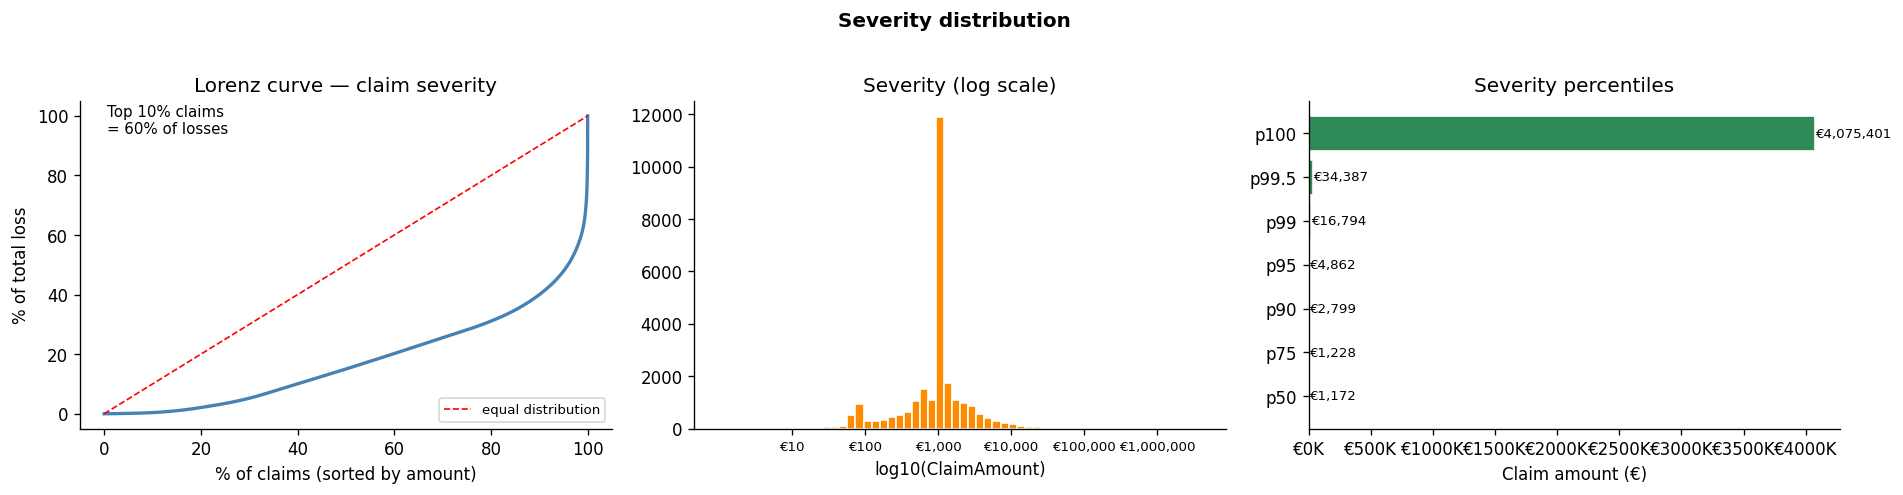

Mean severity:   €2,279
Median severity: €1,172  (mean/median = 1.9x → heavy tail)
Max severity:    €4,075,401


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Lorenz curve of claim amounts
ax = axes[0]
sorted_claims = np.sort(sev['ClaimAmount'].values)
cumulative_claims = np.cumsum(sorted_claims) / sorted_claims.sum()
cumulative_pols = np.arange(1, len(sorted_claims) + 1) / len(sorted_claims)
ax.plot(cumulative_pols * 100, cumulative_claims * 100, color='steelblue', linewidth=2)
ax.plot([0, 100], [0, 100], 'r--', linewidth=1, label='equal distribution')
ax.set_xlabel('% of claims (sorted by amount)')
ax.set_ylabel('% of total loss')
ax.set_title('Lorenz curve — claim severity')
top10_share = 1 - cumulative_claims[int(0.9 * len(sorted_claims))]
ax.text(0.05, 0.9, f'Top 10% claims\n= {top10_share:.0%} of losses', transform=ax.transAxes, fontsize=9)
ax.legend(fontsize=8)

# Log-scale severity histogram
ax = axes[1]
log_sev = np.log10(sev['ClaimAmount'].clip(lower=1))
ax.hist(log_sev, bins=60, color='darkorange', edgecolor='white')
ax.set_xlabel('log10(ClaimAmount)')
ax.set_title('Severity (log scale)')
xticks = [1, 2, 3, 4, 5, 6]
ax.set_xticks(xticks)
ax.set_xticklabels([f'€{10**x:,.0f}' for x in xticks], fontsize=8)

# Percentile table plot
ax = axes[2]
pcts = [50, 75, 90, 95, 99, 99.5, 100]
pct_vals = [np.percentile(sev['ClaimAmount'], p) for p in pcts]
ax.barh([f'p{p}' for p in pcts], pct_vals, color='seagreen', edgecolor='white')
ax.set_xlabel('Claim amount (€)')
ax.set_title('Severity percentiles')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1e3:.0f}K'))
for i, v in enumerate(pct_vals):
    ax.text(v + 1000, i, f'€{v:,.0f}', va='center', fontsize=8)

plt.suptitle('Severity distribution', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean severity:   €{sev["ClaimAmount"].mean():,.0f}')
print(f'Median severity: €{sev["ClaimAmount"].median():,.0f}  (mean/median = {sev["ClaimAmount"].mean()/sev["ClaimAmount"].median():.1f}x → heavy tail)')
print(f'Max severity:    €{sev["ClaimAmount"].max():,.0f}')

## 6. BonusMalus — The Key Risk Signal

BonusMalus is a credibility-weighted score the insurer assigns based on claim history.  
It correlates with both frequency and severity — it's effectively a compressed risk score.  
Models that ignore it or treat it linearly leave money on the table.

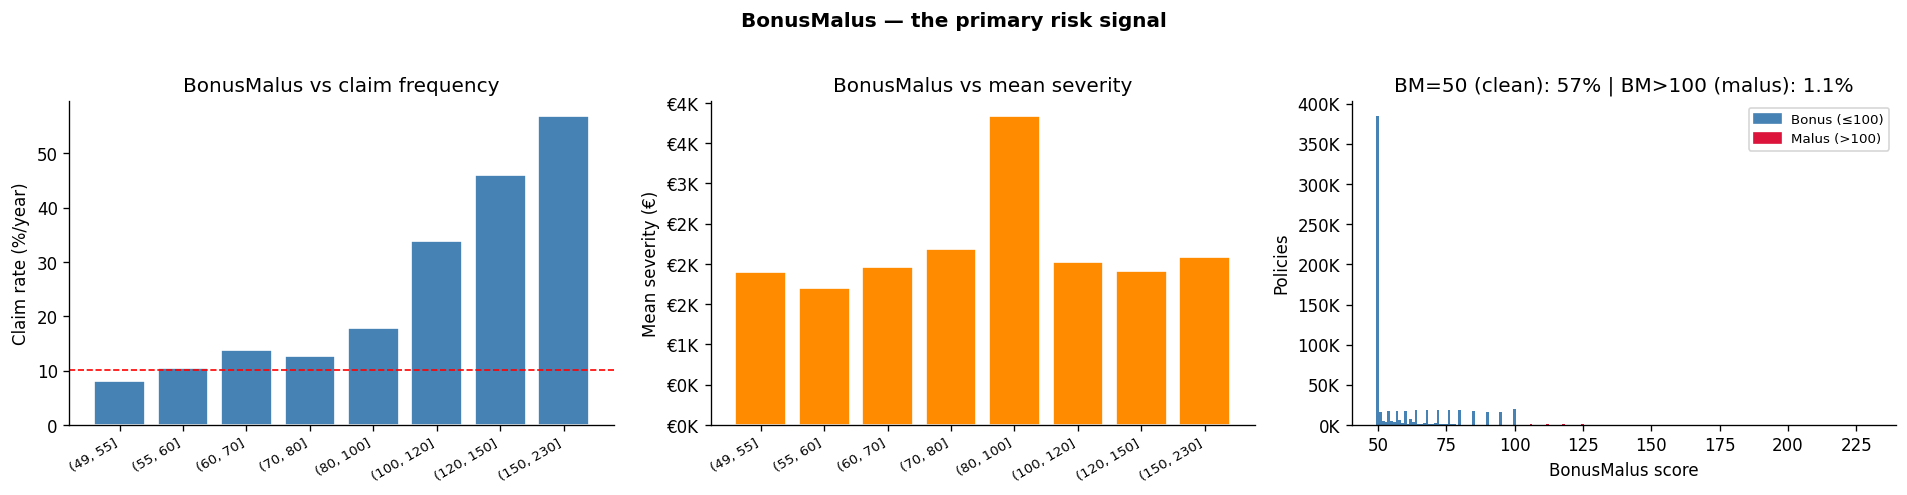

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# BM vs claim frequency
bm_bins = pd.cut(proc['BonusMalus'], bins=[49,55,60,70,80,100,120,150,230])
bm_freq = proc.groupby(bm_bins).agg(claims=('ClaimNb','sum'), exposure=('Exposure','sum'), n=('IDpol','count'))
bm_freq['rate'] = bm_freq['claims'] / bm_freq['exposure']

ax = axes[0]
ax.bar(range(len(bm_freq)), bm_freq['rate'] * 100, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(bm_freq)))
ax.set_xticklabels([str(b) for b in bm_freq.index], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Claim rate (%/year)')
ax.set_title('BonusMalus vs claim frequency')
ax.axhline(proc['ClaimNb'].sum()/proc['Exposure'].sum()*100, color='red', linestyle='--', linewidth=1)

# BM vs mean severity (where claims exist)
claims_only = proc[proc['severity'].notna()].copy()
bm_bins2 = pd.cut(claims_only['BonusMalus'], bins=[49,55,60,70,80,100,120,150,230])
bm_sev = claims_only.groupby(bm_bins2)['severity'].mean()

ax = axes[1]
ax.bar(range(len(bm_sev)), bm_sev.values, color='darkorange', edgecolor='white')
ax.set_xticks(range(len(bm_sev)))
ax.set_xticklabels([str(b) for b in bm_sev.index], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Mean severity (€)')
ax.set_title('BonusMalus vs mean severity')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1e3:.0f}K'))

# BM distribution: clean (50) vs malus
ax = axes[2]
bm_dist = proc['BonusMalus'].value_counts().sort_index()
colors = ['steelblue' if bm <= 100 else 'crimson' for bm in bm_dist.index]
ax.bar(bm_dist.index, bm_dist.values, color=colors, width=1)
clean_pct = (proc['BonusMalus'] == 50).mean()
malus_pct = (proc['BonusMalus'] > 100).mean()
ax.set_xlabel('BonusMalus score')
ax.set_ylabel('Policies')
ax.set_title(f'BM=50 (clean): {clean_pct:.0%} | BM>100 (malus): {malus_pct:.1%}')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Bonus (≤100)'), Patch(color='crimson', label='Malus (>100)')], fontsize=8)

plt.suptitle('BonusMalus — the primary risk signal', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Driver Age — Non-Linear Risk

Young drivers (<25) and seniors (>70) have elevated frequency — a classic U-shape.  
Linear treatment misses this; GLMs need manual interaction terms, GBMs learn it natively.

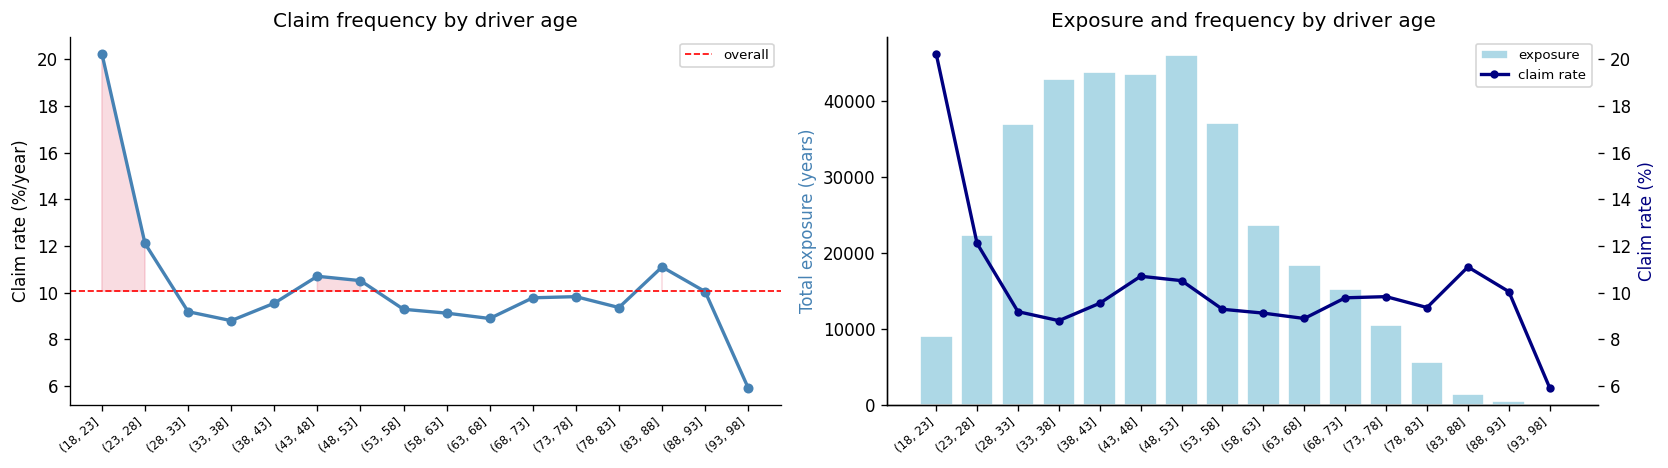

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Freq by DrivAge
ax = axes[0]
age_bins = pd.cut(proc['DrivAge'], bins=range(18, 101, 5))
age_g = proc.groupby(age_bins).agg(claims=('ClaimNb','sum'), exposure=('Exposure','sum'))
age_g['rate'] = age_g['claims'] / age_g['exposure']
ax.plot(range(len(age_g)), age_g['rate'] * 100, marker='o', color='steelblue', linewidth=2, markersize=5)
ax.set_xticks(range(len(age_g)))
ax.set_xticklabels([str(b) for b in age_g.index], rotation=40, ha='right', fontsize=7)
ax.set_ylabel('Claim rate (%/year)')
ax.set_title('Claim frequency by driver age')
ax.axhline(proc['ClaimNb'].sum()/proc['Exposure'].sum()*100, color='red', linestyle='--', linewidth=1, label='overall')
ax.legend(fontsize=8)
ax.fill_between(range(len(age_g)), age_g['rate']*100, 
                proc['ClaimNb'].sum()/proc['Exposure'].sum()*100,
                where=age_g['rate'].values > proc['ClaimNb'].sum()/proc['Exposure'].sum(),
                alpha=0.15, color='crimson', label='above avg')

# Policy count by DrivAge
ax = axes[1]
ax2 = ax.twinx()
ax.bar(range(len(age_g)), age_g['exposure'], color='lightblue', edgecolor='white', label='exposure')
ax2.plot(range(len(age_g)), age_g['rate'] * 100, marker='o', color='navy', linewidth=2, markersize=4, label='claim rate')
ax.set_xticks(range(len(age_g)))
ax.set_xticklabels([str(b) for b in age_g.index], rotation=40, ha='right', fontsize=7)
ax.set_ylabel('Total exposure (years)', color='steelblue')
ax2.set_ylabel('Claim rate (%)', color='navy')
ax.set_title('Exposure and frequency by driver age')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## 8. Feature Correlations & Interactions

Key relationships: BM × DrivAge interaction (young+high-BM is worst), Density (urban = higher freq).

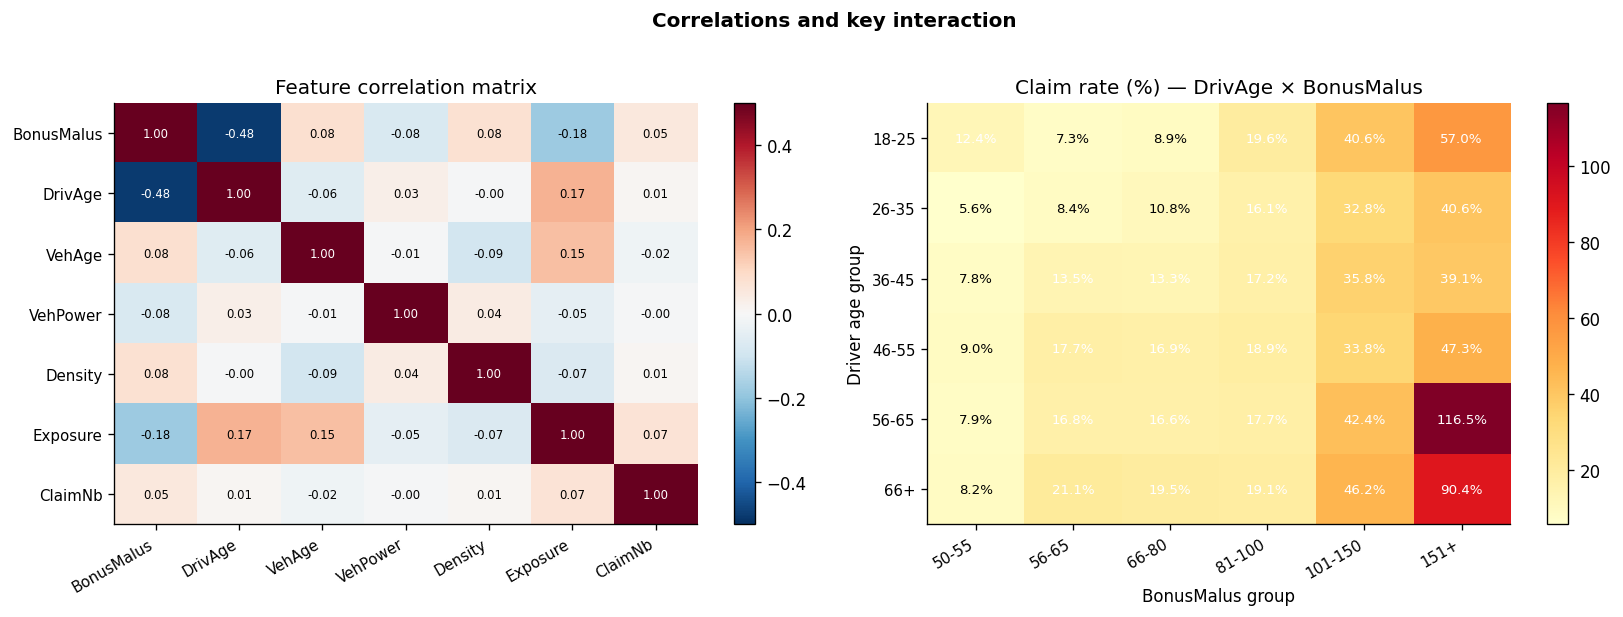

In [10]:
from matplotlib.colors import TwoSlopeNorm

numeric_cols = ['BonusMalus', 'DrivAge', 'VehAge', 'VehPower', 'Density', 'Exposure', 'ClaimNb']
corr = proc[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
ax = axes[0]
norm = TwoSlopeNorm(vmin=-0.5, vcenter=0, vmax=0.5)
im = ax.imshow(corr.values, cmap='RdBu_r', norm=norm, aspect='auto')
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(numeric_cols, fontsize=9)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.values[i,j]) > 0.3 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Feature correlation matrix')

# BM × DrivAge heatmap of claim rate
ax = axes[1]
proc_s = proc.copy()
proc_s['bm_grp'] = pd.cut(proc_s['BonusMalus'], bins=[49,55,65,80,100,150,230], labels=['50-55','56-65','66-80','81-100','101-150','151+'])
proc_s['age_grp'] = pd.cut(proc_s['DrivAge'], bins=[17,25,35,45,55,65,100], labels=['18-25','26-35','36-45','46-55','56-65','66+'])
pivot = proc_s.groupby(['age_grp','bm_grp']).agg(claims=('ClaimNb','sum'), exposure=('Exposure','sum'))
pivot['rate'] = (pivot['claims'] / pivot['exposure'] * 100).round(2)
rate_matrix = pivot['rate'].unstack()

im2 = ax.imshow(rate_matrix.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(rate_matrix.columns)))
ax.set_yticks(range(len(rate_matrix.index)))
ax.set_xticklabels(rate_matrix.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(rate_matrix.index, fontsize=9)
ax.set_xlabel('BonusMalus group')
ax.set_ylabel('Driver age group')
ax.set_title('Claim rate (%) — DrivAge × BonusMalus')
for i in range(rate_matrix.shape[0]):
    for j in range(rate_matrix.shape[1]):
        val = rate_matrix.values[i,j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=8,
                    color='white' if val > 12 else 'black')
plt.colorbar(im2, ax=ax)

plt.suptitle('Correlations and key interaction', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Processed Dataset — Derived Targets

How `processed.parquet` is built from freq+sev join, and what the final target distributions look like.

In [11]:
print('=== Data prep: how processed.parquet is constructed ===')
print()
print('1. freq (678K rows): one row per policy, with ClaimNb')
print('2. sev (26.6K rows): one row per claim payment — multiple per policy possible')
print('3. Join: sev aggregated to policy level (sum of claim amounts)')
print('4. Derived columns:')
print('   claim_flag   = 1 if ClaimNb > 0 else 0')
print('   claim_freq   = ClaimNb (count, not annualised)')
print('   severity     = ClaimAmount_total / ClaimNb  (NaN where ClaimNb=0)')
print('   pure_premium = ClaimAmount_total / Exposure  (€ per year of exposure)')
print()

# Check: policies with ClaimNb>0 but no sev record
has_claims = proc[proc['ClaimNb'] > 0]
no_amount = has_claims[has_claims['ClaimAmount_total'].isna() | (has_claims['ClaimAmount_total'] == 0)]
print(f'Policies with ClaimNb>0: {len(has_claims):,}')
print(f'  of which have ClaimAmount_total > 0: {(has_claims["ClaimAmount_total"] > 0).sum():,}')
print(f'  of which have ClaimAmount_total = 0 or NaN: {len(no_amount):,}  ← IBNR / partial records')
print()

# Pure premium summary by stratum
print('=== Pure premium by risk stratum ===')
proc['bm_group'] = pd.cut(proc['BonusMalus'], bins=[49,55,65,100,150,230], labels=['50-55','56-65','66-100','101-150','151+'])
pp_by_bm = proc.groupby('bm_group')['pure_premium'].agg(['mean','median',lambda x: (x>0).mean()]).round(2)
pp_by_bm.columns = ['mean_pp', 'median_pp', 'claim_rate']
display(pp_by_bm)

=== Data prep: how processed.parquet is constructed ===

1. freq (678K rows): one row per policy, with ClaimNb
2. sev (26.6K rows): one row per claim payment — multiple per policy possible
3. Join: sev aggregated to policy level (sum of claim amounts)
4. Derived columns:
   claim_flag   = 1 if ClaimNb > 0 else 0
   claim_freq   = ClaimNb (count, not annualised)
   severity     = ClaimAmount_total / ClaimNb  (NaN where ClaimNb=0)
   pure_premium = ClaimAmount_total / Exposure  (€ per year of exposure)

Policies with ClaimNb>0: 34,060
  of which have ClaimAmount_total > 0: 24,944
  of which have ClaimAmount_total = 0 or NaN: 9,116  ← IBNR / partial records

=== Pure premium by risk stratum ===


,mean_pp,median_pp,claim_rate
bm_group,,,
50-55,223.43,0.0,0.03
56-65,252.16,0.0,0.05
66-100,858.91,0.0,0.05
101-150,798.49,0.0,0.14
151+,1043.31,0.0,0.19


## 10. Data Quality & Modelling Considerations

Key facts any actuary or ML practitioner should know before fitting a model.

In [12]:
print('=== DATA QUALITY CHECKS ===')
print()

# Missing values
print('Missing values in processed:')
missing = proc.isnull().sum()
print(missing[missing > 0].to_string())
print('  (severity NaN = no claim — expected)')
print()

# Exposure bounds
low_exp = (proc['Exposure'] < 0.05).sum()
print(f'Very short-exposure policies (<0.05yr): {low_exp:,} ({low_exp/len(proc):.1%})')
print(f'  These have high annualised premium variance — often excluded or weighted down')
print()

# Multi-claim policies
multi = (proc['ClaimNb'] > 1).sum()
print(f'Policies with >1 claim: {multi:,} ({multi/len(proc):.2%})')
print(f'Max claims per policy: {proc["ClaimNb"].max()}')
print()

# Pure premium extremes
pp_max = proc['pure_premium'].max()
pp_99 = proc['pure_premium'].quantile(0.999)
above_cap = (proc['pure_premium'] > pp_99).sum()
print(f'Pure premium: max=€{pp_max:,.0f} | 99.9th pct=€{pp_99:,.0f}')
print(f'  Top 0.1% policies: {above_cap:,} — consider winsorisation for regression targets')
print()

print('=== MODELLING NOTES ===')
notes = [
    ('Zero inflation', f'{(proc["pure_premium"]==0).mean():.1%} of policies have zero pure premium → Tweedie or hurdle model'),
    ('Exposure offset', 'All frequency models must use log(Exposure) as offset — not a feature'),
    ('BonusMalus', 'Treat as quasi-continuous; non-linear — GBMs capture it, GLMs need spline/interaction'),
    ('DrivAge', 'U-shaped claim frequency — needs squared term in GLMs'),
    ('Severity tail', f'Mean/median ratio = {sev["ClaimAmount"].mean()/sev["ClaimAmount"].median():.1f}x — Gamma or log-normal severity models are appropriate'),
    ('Train/test split', 'Holdout and CV folds already saved in data/insurance/ — use get_dev_holdout()'),
    ('Adverse selection', 'Target metric = pure premium, not just frequency — models priced too high lose good risks'),
]
for topic, note in notes:
    print(f'  [{topic}] {note}')

=== DATA QUALITY CHECKS ===

Missing values in processed:
severity    653069
  (severity NaN = no claim — expected)

Very short-exposure policies (<0.05yr): 42,386 (6.3%)
  These have high annualised premium variance — often excluded or weighted down

Policies with >1 claim: 1,882 (0.28%)
Max claims per policy: 4

Pure premium: max=€18,524,548 | 99.9th pct=€35,633
  Top 0.1% policies: 679 — consider winsorisation for regression targets

=== MODELLING NOTES ===
  [Zero inflation] 96.3% of policies have zero pure premium → Tweedie or hurdle model
  [Exposure offset] All frequency models must use log(Exposure) as offset — not a feature
  [BonusMalus] Treat as quasi-continuous; non-linear — GBMs capture it, GLMs need spline/interaction
  [DrivAge] U-shaped claim frequency — needs squared term in GLMs
  [Severity tail] Mean/median ratio = 1.9x — Gamma or log-normal severity models are appropriate
  [Train/test split] Holdout and CV folds already saved in data/insurance/ — use get_dev_holdou